# Identified Findings From The Visualisation

## Summary Statistics
- **Total Orders:** 529k  
- **Completed Orders:** 186.9k  
- **Pending Orders:** 310k  
- **Orders In Transit:** 29,239  
- **Total Trucks:** 38 (5 trucks in transit)  

---

## Key Observations and Questions

### 1. Monthly Order Trends
- A sharp rise in order demand was observed in `March(Accra - +746%, Tema - +2151%, Koforidua - +6690%, Bolgatanga - +1847%, Kintampo -+1715%)`, while other months showed a steady distribution of orders.  

**Questions:**  
- What was the average number of orders before March compared to March?  
- Why were there overloaded and underloaded orders in months without a sharp increase in sales?  
- What went wrong in load distribution?  

---

### 2. Missing Trucks
- The truck keys in the orders table accounted for 38 trucks, but only 35 trucks exist in the trucks table.  
- Three trucks are unaccounted for, missing details on type, status, volume, or activities.  

**Questions:**  
- What happened to these 3 missing trucks?  
- Are they broken, decommissioned, or lost due to a data entry error?  
- Could these missing trucks have helped reduce overall truck order volume by 39,000kg?  

---

### 3. Truck Utilization and Distance Optimization
- Kintampo recorded the lowest sales in the monthly distribution of orders.  
- Distance covered by each truck is unknown, but it plays a major role in order distribution.  
- Orders were assigned without considering whether they fully utilized the truck’s capacity.  

**Questions:**  
- How far does each truck travel?  
- Can we merge partially loaded orders in one truck if their destinations are close?  
- Can overloaded trucks redistribute their load to trucks headed to nearby locations?  
  - This will reduce costs and optimize truck utilization.  

---

### 4. March Order Surge and Load Balancing
- Sales surged in March, yet only 35 trucks were available instead of 38.  
- 5 trucks are currently in transit, meaning only 30 trucks are available for new deliveries.
- The 5 trucks currently in transit are currently carrying only 29,239, which could have been done by just 2 trucks and the remaining loaded for other orders
- Weekend truck loads were lower than weekdays.  

**Questions:**  
- How can we distribute sales efficiently across the month?  
- How many times can we fully utilize all trucks to clear outstanding March orders?  
- How can we prevent overload on some days and underutilization on others?

# Truck Availability vs. Order Demand
- If March had a surge in orders, yet 3 trucks were missing, could that have impacted the load balancing issue?  

---

# Order Volume vs. Truck Volume
- The dataset shows that some trucks are overloaded or underutilized, even in months with stable sales.  

---

# Distance-Based Order Merging
- Can orders headed in similar directions be merged into one truck when possible? Can clustering algorithms be applied to the distances? What are the distances of each location from the Lome warehouse and their latitudes/longitutes

---

# Weekend Truck Utilization
- Since weekends had lower truck loads, we could reschedule some weekday orders to avoid overload.  

# 

# Proposed Solutions To The Inefficiencies

1. Dynamic Load Balancing with Location Clustering
Destination Grouping:
Group orders by destination: Kintampo, Tema, Bolgatanga, Koforidua.

Truck Assignment Logic:

Match orders to trucks based on:

Truck capacity (12,000–20,000 kg).

Proximity to destination (geospatial optimization).

Prioritize pending orders over completed/in-transit orders.

Redistribute overloaded in-transit trucks to balance loads.

`Benefits:` 
- Multi-Destination Support if Location grouping was available:
- Extend beyond Kintampo/Tema to include Bolgatanga and Koforidua.


`Feasible?`: `Not Feasible due the fact that no solid data for the location and Proximities are available`

2. `Truck Utilization Optimization`- `Feasible`
- Active Fleet: Use all 30 active trucks (exclude 5 inactive, and the 3 missing).

- Capacity Constraints:

a. Track real capacities (volume_kg column).

b. Monitor loads of 5 in-transit trucks to prevent overloading.
    


3. `Weekly Scheduling` - `Feasible`
- Backlog Clearance:

Distribute all pending orders across days to balance weekday/weekend loads.

Optimize for the March 2025 surge (all orders dated March 2, 2025).



*`Future Implementations`*
- Use clustering algorithms to group orders according to customers (high value and vice versa, and allocate trucks accordingly
- Implement the proximity feature (clustering algo) for trucks and locations closer to each other
- Apply forecasting techniques to predict future orders based on past orders




In [58]:
# import necessary libraries
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

df = pd.read_csv("orders.csv")
df_trucks = pd.read_csv("trucks.csv")
df_centres = pd.read_csv("centres.csv")

print(df.head())
print(df_trucks.head())
print(df_centres.head())

C:\Users\nuell\AppData\Local\Temp\ipykernel_10736\2685465784.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("orders.csv")


   Unnamed: 0                     orderId    clientId         lastModified  \
0           0  01GGAPGS3BZKF3AKKRRHPBCMMG   320232240  2025-03-02 18:20:59   
1           1  01GGAPK4BCXD9S96QXFYD65E20  2420001880  2025-03-02 18:20:59   
2           2  01GGAPRNS3ET0JC79QTAX8PG46   043730707  2025-03-02 18:20:59   
3           3  01GGAPX6EG5S77Y5B39SHNXEAM   028737136  2025-03-02 18:20:59   
4           4  01GGAPYCWBVZQEFFM0DA1J9VT3   038457808  2025-03-02 18:20:59   

    status truckKey  location     fee  volume(kg) deliveryItem  \
0  PENDING      NaN  KINTAMPO  6400.0       340.0          BED   
1  PENDING      NaN  KINTAMPO   320.0        17.0          BED   
2  PENDING      NaN  KINTAMPO  3200.0       170.0          BED   
3  PENDING      NaN  KINTAMPO   640.0        34.0          BED   
4  PENDING      NaN  KINTAMPO  1600.0        85.0          BED   

         dateGenerated  
0  2025-03-02 18:20:59  
1  2025-03-02 18:20:59  
2  2025-03-02 18:20:59  
3  2025-03-02 18:20:59  
4  2025-0

In [17]:
# further info about the orders dataset
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset\n\n")

print(f"Columns in the dataset:")
for column in df.columns:
    print(column)
    
print("\n\n")

print("Brief information about the orders dataset:\n", 
      df.info())

print("\n\n\n")

# further info about the trucks dataset
print(f"There are {df_trucks.shape[0]} rows and {df_trucks.shape[1]} columns in the dataset\n\n")

print(f"Columns in the dataset:")
for column in df_trucks.columns:
    print(column)
    
print("\n\n")

print("Brief information about the trucks dataset:\n", 
      df_trucks.info())


print("\n\n\n")

# further info about the centres dataset
print(f"There are {df_centres.shape[0]} rows and {df_centres.shape[1]} columns in the centres dataset\n\n")

print(f"Columns in the dataset:")
for column in df_centres.columns:
    print(column)
    
print("\n\n")

print("Brief information about the centres dataset:\n", 
      df_centres.info())

There are 526945 rows and 11 columns in the dataset


Columns in the dataset:
Unnamed: 0
orderId
clientId
lastModified
status
truckKey
location
fee
volume(kg)
deliveryItem
dateGenerated



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526945 entries, 0 to 526944
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     526945 non-null  int64  
 1   orderId        526945 non-null  object 
 2   clientId       525702 non-null  object 
 3   lastModified   526945 non-null  object 
 4   status         526945 non-null  object 
 5   truckKey       216170 non-null  object 
 6   location       526945 non-null  object 
 7   fee            526945 non-null  float64
 8   volume(kg)     526945 non-null  float64
 9   deliveryItem   526945 non-null  object 
 10  dateGenerated  526945 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 44.2+ MB
Brief information about the orders dataset:
 None




In [18]:
# identify the missing values for each datatset
print(f"Checking null values for the orders df:")
print(df.isnull().sum())
print("\n\n\n")

print(f"Checking null values for the trucks df:")

print(df_trucks.isnull().sum())
print("\n\n\n")

print(f"Checking null values for the centers df:")
print(df_centres.isnull().sum())



# identify the duplicates for each datatset
print(f"Checking duplicates for the orders df:")
print(df.duplicated().sum())
print("\n\n\n")

print(f"Checking duplicates for the trucks df:")

print(df_trucks.duplicated().sum())
print("\n\n\n")

print(f"Checking duplicates for the centers df:")
print(df_centres.duplicated().sum())

Checking null values for the orders df:
Unnamed: 0            0
orderId               0
clientId           1243
lastModified          0
status                0
truckKey         310775
location              0
fee                   0
volume(kg)            0
deliveryItem          0
dateGenerated         0
dtype: int64




Checking null values for the trucks df:
creationDate    0
encodedKey      0
status          0
truckType       0
volume(kg)      0
dtype: int64




Checking null values for the centers df:
centreId        0
location        0
creationDate    0
dtype: int64
Checking duplicates for the orders df:
0




Checking duplicates for the trucks df:
0




Checking duplicates for the centers df:
0


In [19]:
print(df.describe())
print("\n\n\n")
print(df_trucks.describe())

          Unnamed: 0            fee     volume(kg)
count  526945.000000  526945.000000  526945.000000
mean   263472.000000    4974.850554     263.470034
std    152116.063137   20334.832398    1078.814205
min         0.000000      32.000000       0.000000
25%    131736.000000     640.000000      34.000000
50%    263472.000000    1600.000000      85.000000
75%    395208.000000    3200.000000     170.000000
max    526944.000000  320000.000000   17000.000000




         volume(kg)
count     35.000000
mean   13828.571429
std     2064.912963
min    12000.000000
25%    13000.000000
50%    13000.000000
75%    13000.000000
max    20000.000000


# Changing all data types to their appropriate formats

In [20]:
# Converting the date columns to datetime
df["lastModified"] = pd.to_datetime(df["lastModified"])
df["dateGenerated"] = pd.to_datetime(df["dateGenerated"])
df_trucks["creationDate"] = pd.to_datetime(df_trucks["creationDate"])
df_centres["creationDate"] = pd.to_datetime(df_centres["creationDate"])

# Changinf the volume columns for orders and trucks to float
df["volume(kg)"] = df["volume(kg)"].astype(float)
df_trucks["volume(kg)"] =df_trucks["volume(kg)"].astype(float)

# client to int
df["clientId"] = pd.to_numeric(df["clientId"], errors="coerce")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526945 entries, 0 to 526944
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Unnamed: 0     526945 non-null  int64         
 1   orderId        526945 non-null  object        
 2   clientId       525693 non-null  float64       
 3   lastModified   526945 non-null  datetime64[ns]
 4   status         526945 non-null  object        
 5   truckKey       216170 non-null  object        
 6   location       526945 non-null  object        
 7   fee            526945 non-null  float64       
 8   volume(kg)     526945 non-null  float64       
 9   deliveryItem   526945 non-null  object        
 10  dateGenerated  526945 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(3), int64(1), object(5)
memory usage: 44.2+ MB


In [22]:
# Orders: Status distribution
print(df["status"].value_counts())

print("\n\n")

# Orders: Orders per location
print(df["location"].value_counts())

print("\n\n")

# Trucks: Truck type distribution
print(df_trucks["truckType"].value_counts())

print("\n\n")

# Trucks: Capacity distribution
print(df_trucks["volume(kg)"].describe())

print("\n\n")

# Centres: Unique locations
print(df_centres["location"].unique())

PENDING       310775
COMPLETED     186931
IN_TRANSIT     29239
Name: status, dtype: int64



ACCRA         235077
TEMA          162403
KOFORIDUA      59457
BOLGATANGA     48297
KINTAMPO       21711
Name: location, dtype: int64



BOX_TRUCK       30
REEFER_TRUCK     5
Name: truckType, dtype: int64



count       35.000000
mean     13828.571429
std       2064.912963
min      12000.000000
25%      13000.000000
50%      13000.000000
75%      13000.000000
max      20000.000000
Name: volume(kg), dtype: float64



['KINTAMPO' 'TEMA' 'BOLGATANGA' 'KOFORIDUA' 'ACCRA']


In [23]:
#
# rename conflicting columns
df = df.rename(columns={"volume(kg)": "volume_kgs"})
df_trucks = df_trucks.rename(columns={
    "volume(kg)": "volume_kg",
    "status": "t_status"
})

df["month"] = df["dateGenerated"].dt.month        
df["year"] = df["dateGenerated"].dt.year          

df.drop("Unnamed: 0", axis=1, inplace=True)


df.head()

,orderId,clientId,lastModified,status,truckKey,location,fee,volume_kgs,deliveryItem,dateGenerated,month,year
0,01GGAPGS3BZKF3AKKRRHPBCMMG,3.202322e+08,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,6400.0,340.0,BED,2025-03-02 18:20:59,3,2025
1,01GGAPK4BCXD9S96QXFYD65E20,2.420002e+09,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,320.0,17.0,BED,2025-03-02 18:20:59,3,2025
2,01GGAPRNS3ET0JC79QTAX8PG46,4.373071e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,3200.0,170.0,BED,2025-03-02 18:20:59,3,2025
3,01GGAPX6EG5S77Y5B39SHNXEAM,2.873714e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,640.0,34.0,BED,2025-03-02 18:20:59,3,2025
4,01GGAPYCWBVZQEFFM0DA1J9VT3,3.845781e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,1600.0,85.0,BED,2025-03-02 18:20:59,3,2025


In [24]:
# run a profile report on the current data, but drop the unnamed column
from ydata_profiling import ProfileReport

df.profile_report()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
# merge the trucks and orders
data = df.merge(df_trucks, left_on="truckKey", right_on="encodedKey", how="left")
data.head()

,orderId,clientId,lastModified,status,truckKey,location,fee,volume_kgs,deliveryItem,dateGenerated,month,year,creationDate,encodedKey,t_status,truckType,volume_kg
0,01GGAPGS3BZKF3AKKRRHPBCMMG,3.202322e+08,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,6400.0,340.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
1,01GGAPK4BCXD9S96QXFYD65E20,2.420002e+09,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,320.0,17.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
2,01GGAPRNS3ET0JC79QTAX8PG46,4.373071e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,3200.0,170.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
3,01GGAPX6EG5S77Y5B39SHNXEAM,2.873714e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,640.0,34.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
4,01GGAPYCWBVZQEFFM0DA1J9VT3,3.845781e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,1600.0,85.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN


In [26]:

# Find trucks currently in transit based on order status
in_transit_trucks = data[data["status"] == "IN_TRANSIT"]["truckKey"].unique()

# Find available trucks: "t_status" == "ACTIVE" and not in transit
available_trucks = df_trucks[(df_trucks["t_status"] == "ACTIVE") & (~df_trucks["encodedKey"].isin(in_transit_trucks))]

# Filter pending orders from the merged data
pending_orders = data[data["status"] == "PENDING"]

# Group pending orders by location and sort by volume_kgs (descending)
pending_by_location = {location: group.sort_values("volume_kgs", ascending=False)
                       for location, group in pending_orders.groupby("location")}

# Sort available trucks by volume_kg (descending)
available_trucks = available_trucks.sort_values("volume_kg", ascending=False)

In [27]:
# break down the truck in transit to sizing 

In [28]:
# Find trucks currently in transit based on order status, but do a print() console log
# on every line to find where the errors are emerging from
in_transit_trucks = data[data["status"] == "IN_TRANSIT"]["truckKey"].unique()
in_transit_trucks

array(['8a858f5b8101e7c901811e75b191610d',
       '8a858f46813e54820181495b67cc468b',
       '8a858fe989d6707c0189d988c570764a',
       '8a858fc48e15f69d018e1d0c55ac3213',
       '8a858f1989d8b5e10189d95ed4a01ee2'], dtype=object)

In [29]:
# Find available trucks: "t_status" == "ACTIVE" and not in transit
available_trucks = df_trucks[(df_trucks["t_status"] == "ACTIVE") & (~df_trucks["encodedKey"].isin(in_transit_trucks))]
available_trucks
# Check if we have any available trucks
if available_trucks.empty:
    print("No available trucks found! Cannot process orders.")


In [30]:

# Sort available trucks by volume_kg 
available_trucks = available_trucks.sort_values("volume_kg", ascending=False)
available_trucks

,creationDate,encodedKey,t_status,truckType,volume_kg
34,2021-11-11 09:32:51,8a858f597d0b7853017d0e57bf32474b,ACTIVE,REEFER_TRUCK,20000.0
33,2020-08-20 16:41:56,8a858f47740be19501740cbede15691b,ACTIVE,REEFER_TRUCK,20000.0
30,2024-10-15 09:57:07,8a858ec2928b13d401928f9aa132431a,ACTIVE,BOX_TRUCK,15000.0
23,2024-03-08 08:55:40,8a858fed8e15ce31018e1d2865003e8a,ACTIVE,BOX_TRUCK,15000.0
4,2022-12-06 15:03:23,8a858f4c84e67fe60184e7f2f7d05fc3,ACTIVE,BOX_TRUCK,13000.0
32,2020-06-17 10:46:35,8a858f8a72c15fc80172c1e05ae85385,ACTIVE,BOX_TRUCK,13000.0
29,2024-10-01 10:18:12,8a858e2c92472ba201924796684e07b7,ACTIVE,BOX_TRUCK,13000.0
27,2024-08-27 15:09:21,8a858e75916c1cea01919461a63155bb,ACTIVE,BOX_TRUCK,13000.0
25,2024-07-05 08:25:12,8a858f6e907f8f4e019081fc71871c29,ACTIVE,BOX_TRUCK,13000.0
24,2024-03-08 09:16:29,8a858ebb8e15ce2c018e1d50f7944865,ACTIVE,BOX_TRUCK,13000.0


In [31]:

# Filter pending orders from the merged data
pending_orders = data[data["status"] == "PENDING"]
# Check if we have any pending orders
if pending_orders.empty:
    print("No pending orders found!")

pending_orders

,orderId,clientId,lastModified,status,truckKey,location,fee,volume_kgs,deliveryItem,dateGenerated,month,year,creationDate,encodedKey,t_status,truckType,volume_kg
0,01GGAPGS3BZKF3AKKRRHPBCMMG,3.202322e+08,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,6400.0,340.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
1,01GGAPK4BCXD9S96QXFYD65E20,2.420002e+09,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,320.0,17.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
2,01GGAPRNS3ET0JC79QTAX8PG46,4.373071e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,3200.0,170.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
3,01GGAPX6EG5S77Y5B39SHNXEAM,2.873714e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,640.0,34.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
4,01GGAPYCWBVZQEFFM0DA1J9VT3,3.845781e+07,2025-03-02 18:20:59,PENDING,NaN,KINTAMPO,1600.0,85.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340007,01J187EZP99VWRDBRA208GKMDY,1.735407e+07,2025-03-02 18:20:59,PENDING,NaN,ACCRA,320.0,17.0,TABLE,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
340008,01J187WA3ASVB0BRSEP7M2BM4Q,5.960839e+08,2025-03-02 18:20:59,PENDING,NaN,ACCRA,544.0,28.9,TABLE,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
340009,01J188AKG5F6Y5QK85ZE9S9V88,6.047116e+08,2025-03-02 18:20:59,PENDING,NaN,ACCRA,6400.0,340.0,BED,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN
340012,01J189EMS0JB0QX69D8R7MKHZ9,5.128670e+08,2025-03-02 18:20:59,PENDING,NaN,ACCRA,320.0,17.0,TABLE,2025-03-02 18:20:59,3,2025,NaT,NaN,NaN,NaN,NaN


In [74]:
# Group pending orders by location
pending_by_location = {
    location: group.sort_values("volume_kgs", ascending=True)  
    for location, group in pending_orders.groupby("location")
}

pending_by_location

{'ACCRA':                            orderId      clientId        lastModified   status  \
 335343  01J0RF9Q5MWD6WAA60QCQ5ZRHX  9.671804e+08 2025-03-02 18:20:59  PENDING   
 268663  01HS8WDM2C3TTC25KAAKR09T5J  1.357532e+08 2025-03-02 18:20:59  PENDING   
 316958  01HYXD7T13C6GGMTMSJ35SNDGC  5.539620e+08 2025-03-02 18:20:59  PENDING   
 49992   01GV689DTT2RAR71J7ZN8RWD4H  7.043305e+08 2025-03-02 18:20:59  PENDING   
 239958  01HP23JECMMK2ZHZ9FCWCTG0JM  3.742556e+08 2025-03-02 18:20:59  PENDING   
 ...                            ...           ...                 ...      ...   
 137570  01H9R1GWBFZKPNCYGS325G62JE  1.976145e+08 2025-03-02 18:20:59  PENDING   
 187904  01HFS717R4NVG0MFSA3VGVS7ED  8.907468e+07 2025-03-02 18:20:59  PENDING   
 137537  01H9R0DDVEC7GGPRZMREKHAPZ0  7.339665e+08 2025-03-02 18:20:59  PENDING   
 236096  01HNJTZXKQ2SAVRVSF6Q7BJ286  7.955478e+08 2025-03-02 18:20:59  PENDING   
 308146  01HXW08E6KE2HDVT7XBNBM0V5Z  2.420000e+09 2025-03-02 18:20:59  PENDING   
 
     

In [33]:
# Pre-calculate total volumes for each location
location_total_volumes = {
    loc: group["volume_kgs"].sum() 
    for loc, group in pending_by_location.items()
}

location_total_volumes

{'ACCRA': 9158169.280000001,
 'BOLGATANGA': 3187030.477,
 'KINTAMPO': 1381981.0,
 'KOFORIDUA': 3590683.0500000003,
 'TEMA': 9564523.68}

In [34]:
# Check if we have any extreme cases where our orders too large for any truck availabnle
max_truck_capacity = available_trucks["volume_kg"].max() if not available_trucks.empty else 0

max_truck_capacity

20000.0

In [72]:
# check if the orders are biigger than the trukc in question
oversized_orders = pending_orders[pending_orders["volume_kgs"] > max_truck_capacity]
if not oversized_orders.empty:
    print(f"Warning: {len(oversized_orders)} orders exceed the capacity of the largest truck!")


In [36]:
# print(pending_by_location)

# Assigning Trips For Orders

In [37]:
# Assigning trips but console logging each step to identify where the assignment isnt taking place
trips = []
i = 0

# First calculate total volumes once outside the loop
total_volumes = {loc: group["volume_kgs"].sum() for loc, group in pending_by_location.items() if len(group) > 0}
# print(f"Total Volume:\n {total_volumes}")

while any(len(group) > 0 for group in pending_by_location.values()):
    # Select truck in round-robin fashion
    truck = available_trucks.iloc[i % len(available_trucks)]
    # print(f"Truck:\n{truck}")
    
    if not total_volumes:
        break
    
    # findign the location with the highest total volume left
    location = max(total_volumes, key=total_volumes.get)
    # print(f"Loc with highest vol:\n {location}")
    
    # Geting all orders for this location
    location_orders = pending_by_location[location]
    # print(f"Location orders:\n {location}")
    
    # Sorting orders by volume 
    location_orders = location_orders.sort_values("volume_kgs")
    # print(f"Location orders again:\n {location}")

    
    # Do a cummulative assignment
    cumulative_volume = location_orders["volume_kgs"].cumsum()
    # print(f"Cummulative Vol:\n {cumulative_volume}")

    mask = cumulative_volume <= truck["volume_kg"]
    # print(f"Mask:\n {mask}")
    
    # Get orders that can be assigned
    assignable_orders = location_orders[mask]
    # print(f"Assignable Orders:\n {assignable_orders}")
    
    if assignable_orders.empty:
        # Take at least one order if possible
        if not location_orders.empty:
            assignable_orders = location_orders.iloc[[0]]
    
    # Record trip
    if not assignable_orders.empty:
        assigned_order_ids = assignable_orders["orderId"].tolist()
        current_load = assignable_orders["volume_kgs"].sum()
        
        trips.append({
            "truck": truck["encodedKey"],
            "location": location,
            "orders": assigned_order_ids,
            "total_load": current_load,
            "truck_capacity": truck["volume_kg"]
        })
        # print(f"Current Trips:\n {trips}")
        
        # Update pendingo orders using more with indexing technique
        pending_by_location[location] = location_orders[~location_orders["orderId"].isin(assigned_order_ids)]
        
        # Update total volume for this location
        if len(pending_by_location[location]) > 0:
            total_volumes[location] = pending_by_location[location]["volume_kgs"].sum()
        else:
            total_volumes.pop(location, None)
    else:
        # Remove location if we can"t fit any orders
        total_volumes.pop(location, None)
    
    i += 1

# print(trips)

# Distribution of Orders 

In [38]:
# Create 7 days
days = [[] for _ in range(7)]
daily_loads = [0] * 7  # Track total load for each day

# Assign trips to minimize load differences
for trip in sorted(trips, key=lambda x: x["total_load"], reverse=True):
    # Find the day with minimum current load
    min_load_day = daily_loads.index(min(daily_loads))
    
    # Assign trip to that day
    days[min_load_day].append(trip)
    
    # Update the daily load
    daily_loads[min_load_day] += trip["total_load"]

# Trip Distribution

In [39]:
# what are the total trips and volume we can deliver
total_trips = len(trips)
print(f"Total Trips:\n\n {total_trips}")
total_volume_delivered = sum(trip["total_load"] for trip in trips)
print(f"Total Vol:\n\n {total_volume_delivered}")

average_load_per_trip = total_volume_delivered / total_trips if total_trips > 0 else 0

# Calculate utilization as (total_load / truck_capacity) * 100 for each trip
utilizations = [(trip["total_load"] / trip["truck_capacity"]) * 100 for trip in trips]
average_utilization = sum(utilizations) / len(utilizations) if utilizations else 0
print(f"Total Trips Assigned: {total_trips}")
print(f"Total Volume Delivered: {total_volume_delivered:.2f} kg")
print(f"Average Load per Trip: {average_load_per_trip:.2f} kg")
print(f"Average Truck Utilization: {average_utilization:.2f}%")

Total Trips:

 1979
Total Vol:

 26882387.48700001
Total Trips Assigned: 1979
Total Volume Delivered: 26882387.49 kg
Average Load per Trip: 13583.82 kg
Average Truck Utilization: 99.28%


In [40]:
print("\nWeekly Schedule Summary:")
for day, day_trips in enumerate(days):
    day_volume = sum(trip["total_load"] for trip in day_trips)
    day_orders = sum(len(trip["orders"]) for trip in day_trips)
    print(f"Day {day + 1}: {len(day_trips)} trips, {day_orders} orders, {day_volume:.2f} kg")


Weekly Schedule Summary:
Day 1: 284 trips, 45261 orders, 3839789.32 kg
Day 2: 283 trips, 42453 orders, 3839385.40 kg
Day 3: 282 trips, 46519 orders, 3839183.12 kg
Day 4: 282 trips, 44116 orders, 3839157.26 kg
Day 5: 283 trips, 42134 orders, 3838928.27 kg
Day 6: 282 trips, 46314 orders, 3839236.31 kg
Day 7: 283 trips, 43978 orders, 3846707.81 kg


In [41]:
# Identify potential issues
max_day_volume = max(sum(trip["total_load"] for trip in day_trips) for day_trips in days)
min_day_volume = min(sum(trip["total_load"] for trip in day_trips) for day_trips in days if day_trips)
volume_imbalance = (max_day_volume - min_day_volume) / max_day_volume * 100 if max_day_volume > 0 else 0

print(f"\nVolume Imbalance Across Days: {volume_imbalance:.2f}%")

# Find any overloaded trips
overloaded_trips = [trip for trip in trips if trip["total_load"] > trip["truck_capacity"]]
if overloaded_trips:
    print(f"\nWarning: {len(overloaded_trips)} trips exceed truck capacity")


Volume Imbalance Across Days: 0.20%


In [42]:
# # Should come before the while loop
# print("Number of locations with pending orders:", len(pending_by_location))
# for loc, group in pending_by_location.items():
#     print(f"Location {loc}: {len(group)} orders")
# print("Number of available trucks:", len(available_trucks))

Number of locations with pending orders: 5
Location ACCRA: 0 orders
Location BOLGATANGA: 0 orders
Location KINTAMPO: 0 orders
Location KOFORIDUA: 0 orders
Location TEMA: 0 orders
Number of available trucks: 25


In [43]:
# print(trips)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



# Part 3 - Key Metrics

In [56]:
# putting the trips into a datafrane, first create an empty list
trips_with_day = []
for day_index, day_trips in enumerate(days):
    for trip in day_trips:
        # Add a "day" field to give day 1-7
        trip["day"] = day_index + 1
        trips_with_day.append(trip)

df_trips = pd.DataFrame(trips_with_day)

# Calculating the % truck utilization for each trip 
df_trips["utilization"] = df_trips.apply(lambda row: (row["total_load"] / row["truck_capacity"]) * 100, axis=1)

#  Aggregating my weekly metrics for further analysis
weekly_metrics = df_trips.groupby("day").agg(
    trip_count=("truck", "count"),
    orders_count=("orders", lambda x: sum(len(lst) for lst in x)),
    total_volume=("total_load", "sum"),
    avg_utilization=("utilization", "mean")
).reset_index()

print(f"Weekly Metrics:\n{weekly_metrics}")



Weekly Metrics:
   day  trip_count  orders_count  total_volume  avg_utilization
0    1         284         45261   3839789.320        98.868528
1    2         283         42453   3839385.400        99.163015
2    3         282         46519   3839183.117        99.456292
3    4         282         44116   3839157.260        99.455719
4    5         283         42134   3838928.270        99.124041
5    6         282         46314   3839236.310        99.457907
6    7         283         43978   3846707.810        99.467616


In [76]:
df_trips.head()

,truck,location,orders,total_load,truck_capacity,day,utilization
0,8a858f597d0b7853017d0e57bf32474b,KOFORIDUA,"[01GZKP6THP9Q6D33B0ADY1012Q, 01H16FE64T95W4HBP...",19995.4,20000.0,1,99.977
1,8a858f47740be19501740cbede15691b,ACCRA,"[01HA1RXEHDEX88DEKCE94HGD65, 01J0XH4EHCW9CYC79...",19992.0,20000.0,1,99.960
2,8a858f597d0b7853017d0e57bf32474b,TEMA,"[01H8KF6BSSZTBXWVFTH12KJ93P, 01GH9NBNEX02XBXFF...",19992.0,20000.0,1,99.960
3,8a858f47740be19501740cbede15691b,ACCRA,"[01HVH9K4H4CTE6H17KHY6MZ25K, 01HZM28CVNXXNC971...",19992.0,20000.0,1,99.960
4,8a858f597d0b7853017d0e57bf32474b,BOLGATANGA,"[01GHVAF97XB1XE7QX3NEQZVRK8, 01HAMJPYDHXV9KQG6...",19992.0,20000.0,1,99.960


In [ ]:
# comparig the number of trips, order counts, and total volume delivered per for each day
days_labels = [f"Day {day}" for day in weekly_metrics["day"]]
x = np.arange(len(weekly_metrics))
width = 0.25

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.bar(x - width, weekly_metrics["trip_count"], width, label="Trip Count")
# ax.bar(x, weekly_metrics["orders_count"], width, label="Order Count")
# ax.bar(x + width, weekly_metrics["total_volume"], width, label="Volume Delivered (kg)")

# ax.set_xticks(x)
# ax.set_xticklabels(days_labels)
# ax.set_xlabel("Day")
# ax.set_title("Weekly Delivery Metrics")
# ax.legend()
# plt.show()

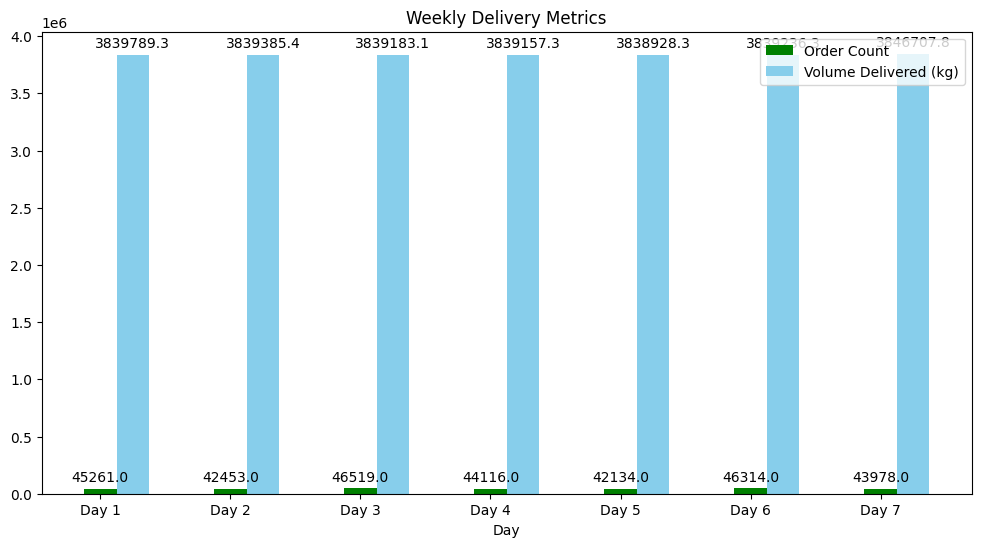

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))
# bars1 = ax.bar(x - width, weekly_metrics["trip_count"], width, label="Trip Count", color="blue")
bars2 = ax.bar(x, weekly_metrics["orders_count"], width, label="Order Count", color="green")
bars3 = ax.bar(x + width, weekly_metrics["total_volume"], width, label="Volume Delivered (kg)", color="skyblue")

ax.set_xticks(x)
ax.set_xticklabels(days_labels)
ax.set_xlabel("Day")
ax.set_title("Weekly Delivery Metrics")
ax.legend()

# Optionally annotate bars to see the values
for bar in bars2 + bars3:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom")

plt.show()


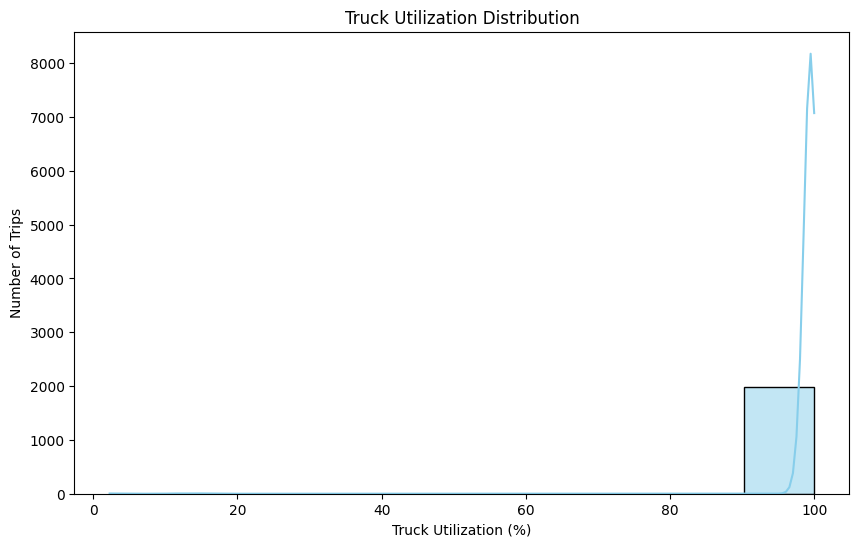

In [62]:
# showing the distribution of truck utilization percentages.
plt.figure(figsize=(10, 6))
sns.histplot(df_trips["utilization"], bins=10, kde=True, color="skyblue", edgecolor="black")
plt.title("Truck Utilization Distribution")
plt.xlabel("Truck Utilization (%)")
plt.ylabel("Number of Trips")
plt.show()



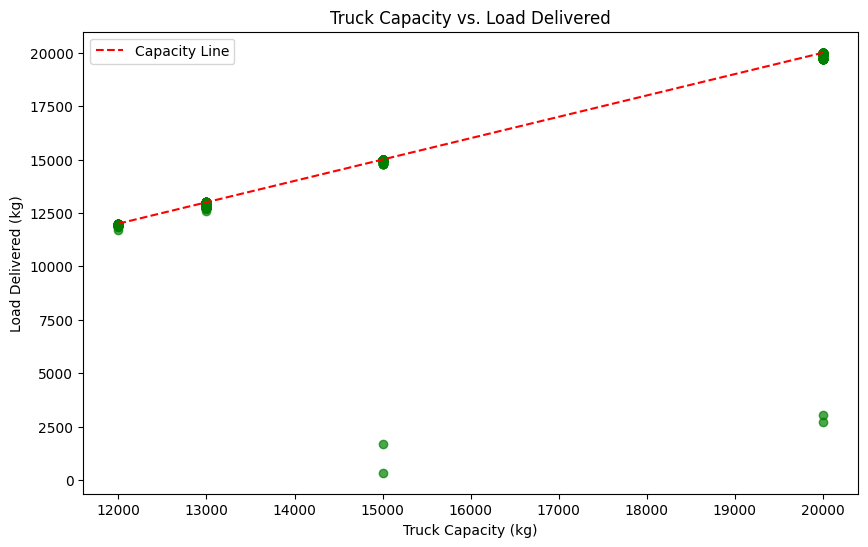

In [63]:

# comparing each trip"s load to the truck capacity
plt.figure(figsize=(10, 6))
plt.scatter(df_trips["truck_capacity"], df_trips["total_load"], alpha=0.7, color="green")
min_cap = df_trips["truck_capacity"].min()
max_cap = df_trips["truck_capacity"].max()
plt.plot([min_cap, max_cap], [min_cap, max_cap], "r--", label="Capacity Line")
plt.xlabel("Truck Capacity (kg)")
plt.ylabel("Load Delivered (kg)")
plt.title("Truck Capacity vs. Load Delivered")
plt.legend()
plt.show()




C:\Users\nuell\AppData\Local\Temp\ipykernel_10736\3209885240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_load', data=df_trips, palette="vlag")


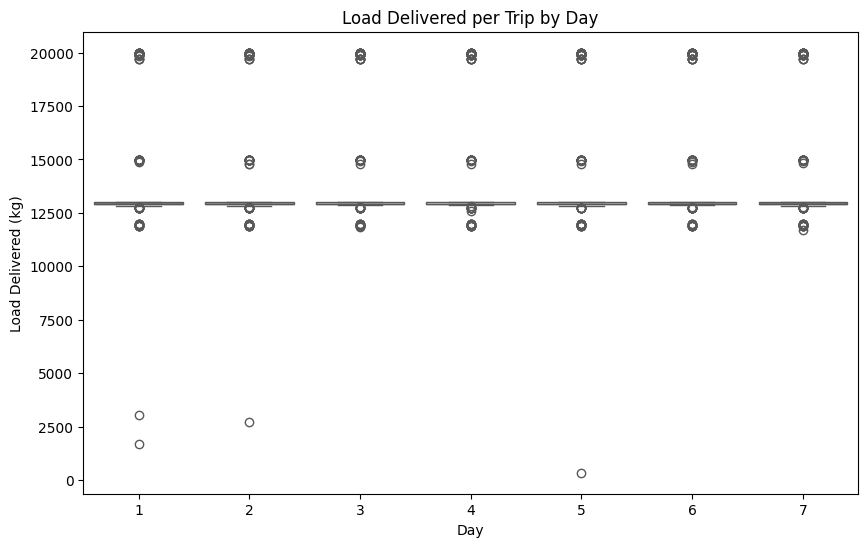

In [64]:
# checking how scattered the load delivered for trips are across each day.
plt.figure(figsize=(10,6))
sns.boxplot(x="day", y="total_load", data=df_trips, palette="vlag")
plt.title("Load Delivered per Trip by Day")
plt.xlabel("Day")
plt.ylabel("Load Delivered (kg)")
plt.show()


In [78]:
try:
    df_trips.to_csv("transformed_data.csv", index=False)
    print("Data has been saved successfully as transformed_data.csv")
except Exception as e:
    print("An error occurred while saving the data:", e)


Data has been saved successfully as transformed_data.csv
